In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

rcParams['figure.dpi'] = 500
rcParams['savefig.dpi'] = 500
rcParams['font.family'] = 'Arial'
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 14
rcParams['xtick.labelsize'] = 14
rcParams['ytick.labelsize'] = 14
rcParams['legend.fontsize'] = 14
rcParams['figure.titlesize'] = 16

mmi_colors = {
        'I': '#B9D3F6',    # Light blue
        'II': '#9FC5F4',
        'III': '#86B7F2',  # Blue
        'IV': '#70E7F7',   # Cyan
        'V': '#92E285',    # Green
        'VI': '#FFFF00',   # Yellow
        'VII': '#FFC800',  # Orange
        'VIII': '#FF9100', # Dark orange
        'IX': '#FF0000',   # Red
        'X': '#C80000',    # Dark red
        'XI': '#A00000',   # Darker red
        'XII': '#800000'   # Very dark red
    }

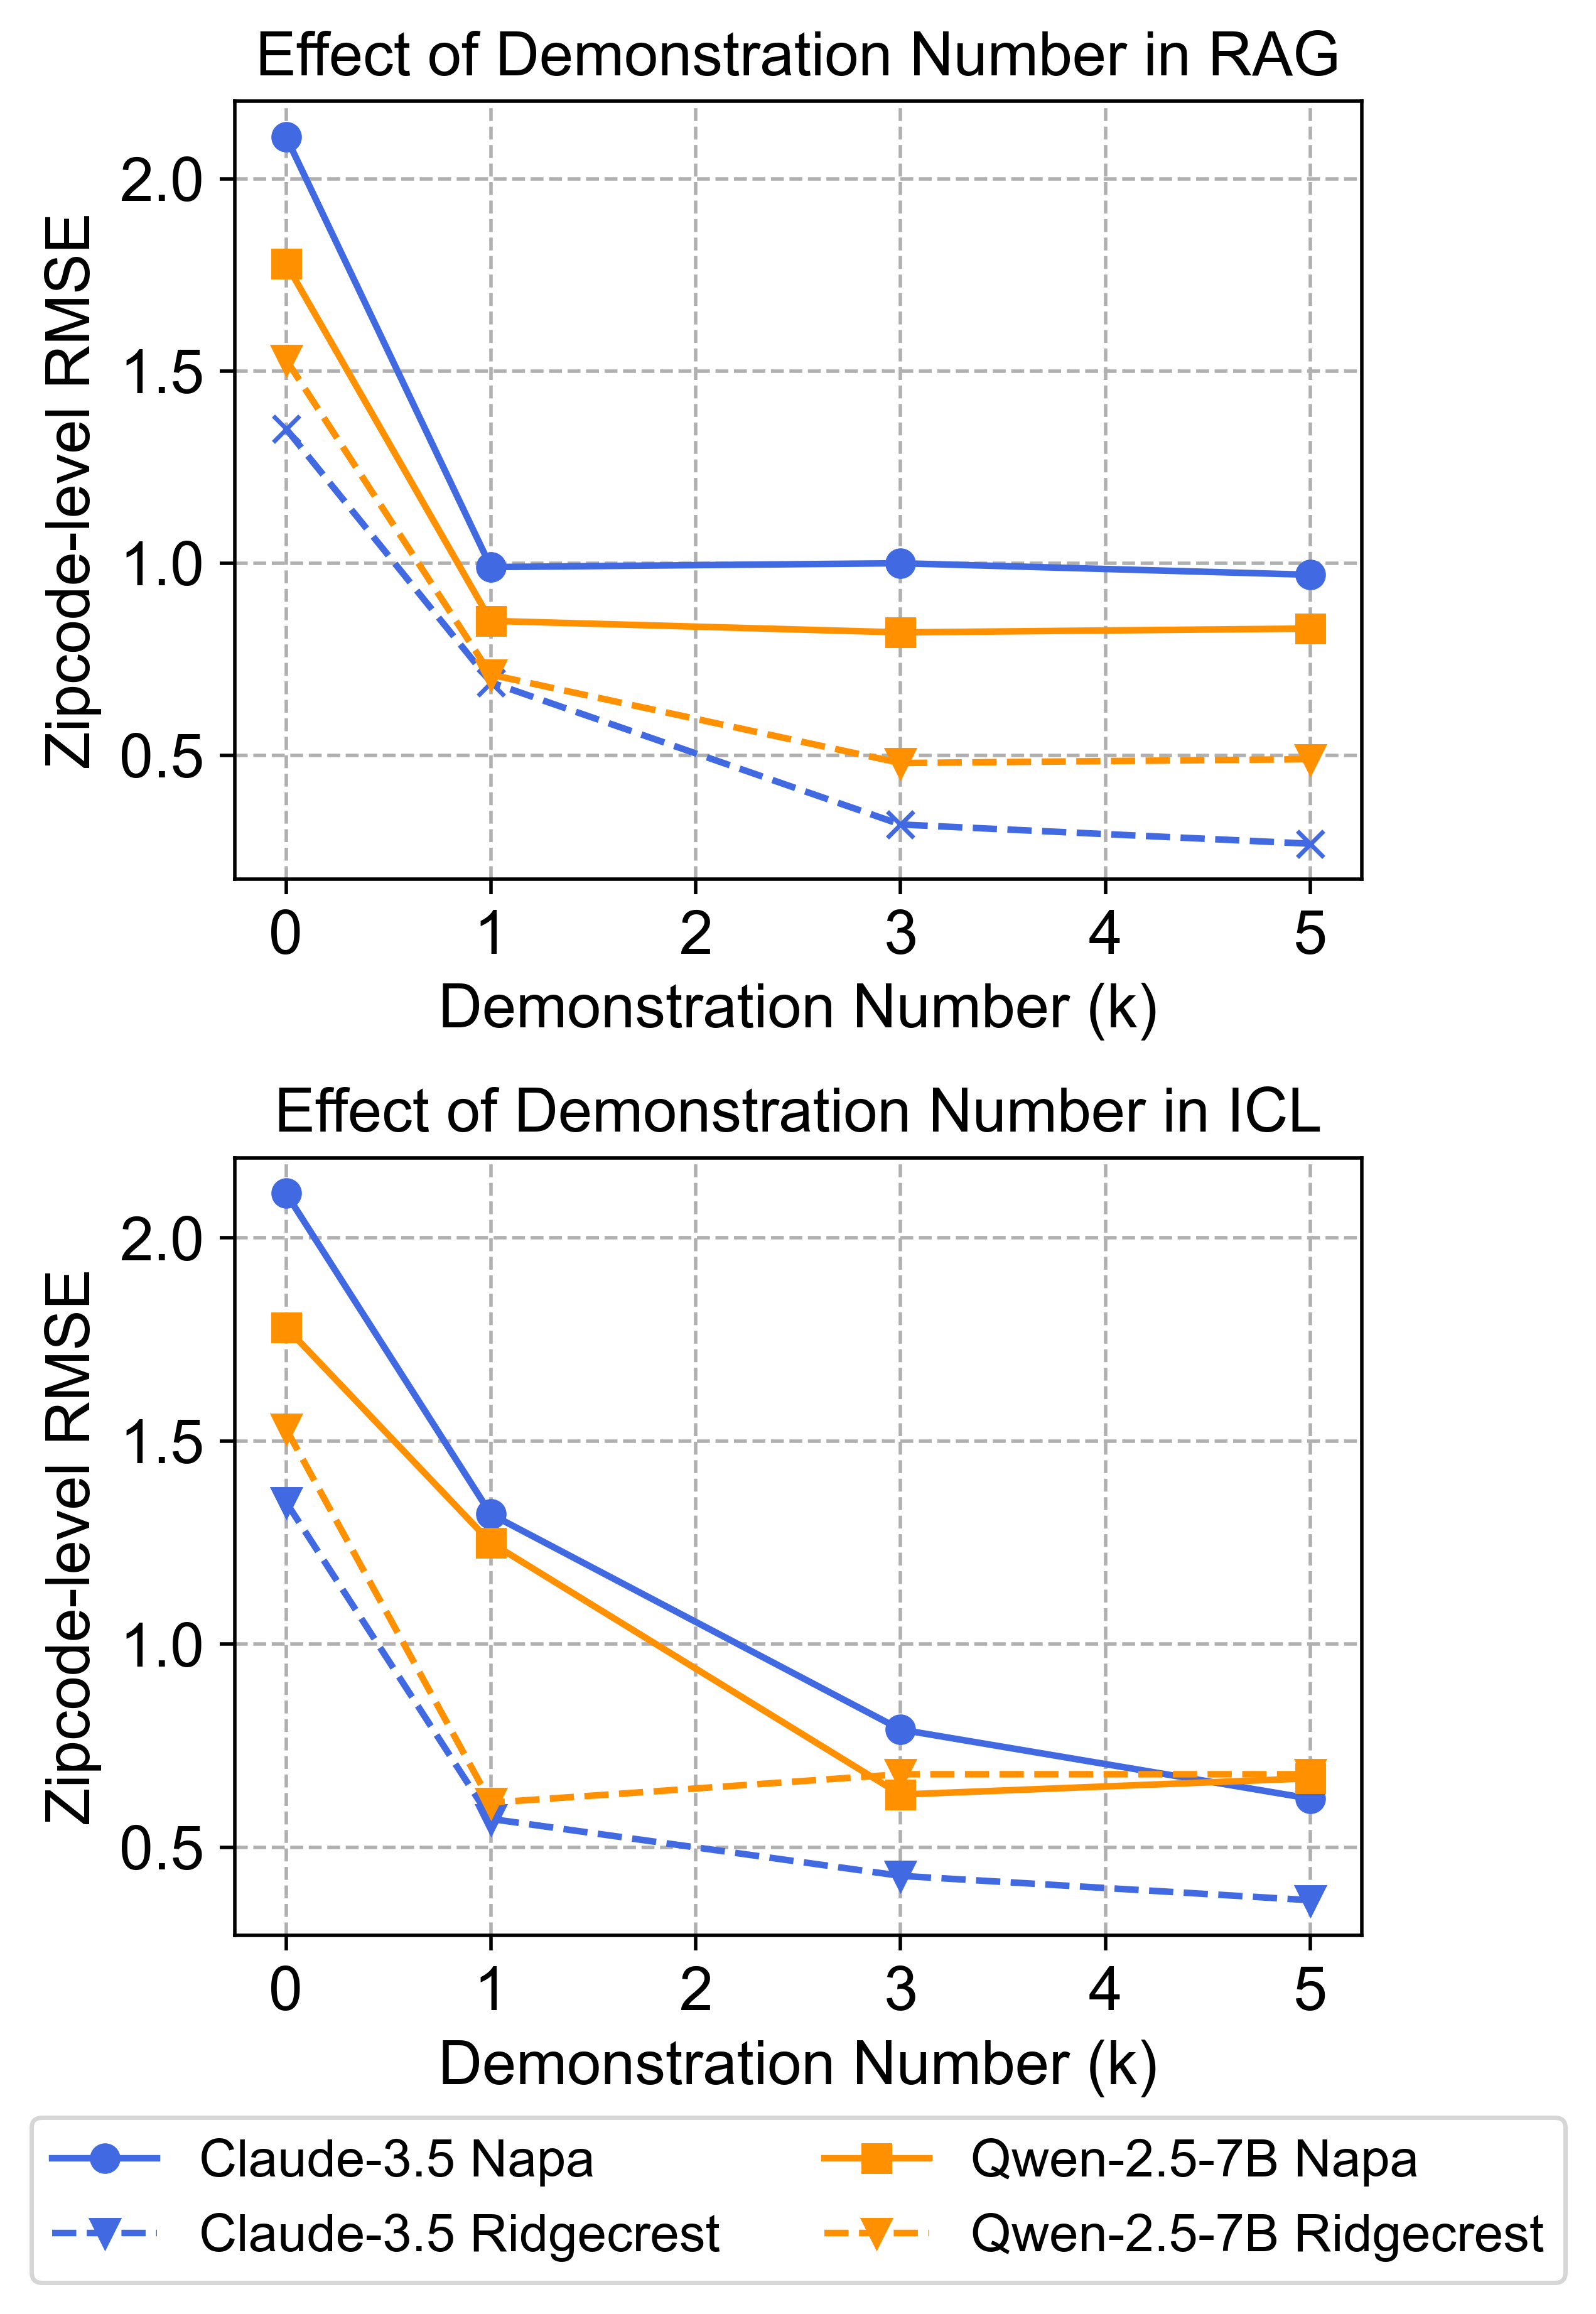

In [4]:
# Claude-3.5 haiku
claude_rag_napa = [0.99, 1.00, 0.97]
claude_rag_ridgecrest = [0.69, 0.32, 0.27]

claude_icl_napa = [1.32, 0.79, 0.62]
claude_icl_ridgecrest = [0.57, 0.43, 0.37]

# Qwen-2.5 7B Instruct
qwen_rag_napa = [0.85, 0.82, 0.83]
qwen_rag_ridgecrest = [0.71, 0.48, 0.49]

qwen_icl_napa = [1.25, 0.63, 0.67]
qwen_icl_ridgecrest = [0.61, 0.68, 0.68]

# Including baseline results (demonstration = 0)
k_values_extended = [0, 1, 3, 5]

# Adding baseline results for Claude
claude_rag_napa_baseline = [2.11] + claude_rag_napa
claude_rag_ridgecrest_baseline = [1.35] + claude_rag_ridgecrest
claude_icl_napa_baseline = [2.11] + claude_icl_napa
claude_icl_ridgecrest_baseline = [1.35] + claude_icl_ridgecrest

# Adding baseline results for Qwen
qwen_rag_napa_baseline = [1.78] + qwen_rag_napa
qwen_rag_ridgecrest_baseline = [1.53] + qwen_rag_ridgecrest
qwen_icl_napa_baseline = [1.78] + qwen_icl_napa
qwen_icl_ridgecrest_baseline = [1.53] + qwen_icl_ridgecrest

# Plotting two subfigures: RAG and ICL with baseline
fig, axes = plt.subplots(2, 1, figsize=(5, 7.5))

# RAG subfigure
axes[0].plot(k_values_extended, claude_rag_napa_baseline, marker='o', linestyle='-', label='Claude-3.5 Napa', color="royalblue")
axes[0].plot(k_values_extended, claude_rag_ridgecrest_baseline, marker='x', linestyle='--', label='Claude-3.5 Ridgecrest', color="royalblue")
axes[0].plot(k_values_extended, qwen_rag_napa_baseline, marker='s', linestyle='-', label='Qwen-2.5-7B Napa', color="#FF9100")
axes[0].plot(k_values_extended, qwen_rag_ridgecrest_baseline, marker='v', linestyle='--', label='Qwen-2.5-7B Ridgecrest', color="#FF9100")
axes[0].set_xlabel('Demonstration Number (k)')
axes[0].set_ylabel('Zipcode-level RMSE')
axes[0].set_title('Effect of Demonstration Number in RAG', )
axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')
axes[0].grid(True, linestyle='--')

# ICL subfigure
axes[1].plot(k_values_extended, claude_icl_napa_baseline, marker='o', linestyle='-', label='Claude-3.5 Napa', color="royalblue")
axes[1].plot(k_values_extended, claude_icl_ridgecrest_baseline, marker='v', linestyle='--',  label='Claude-3.5 Ridgecrest', color="royalblue")
axes[1].plot(k_values_extended, qwen_icl_napa_baseline, marker='s', linestyle='-', label='Qwen-2.5-7B Napa', color="#FF9100")
axes[1].plot(k_values_extended, qwen_icl_ridgecrest_baseline, marker='v', linestyle='--', label='Qwen-2.5-7B Ridgecrest', color="#FF9100")
axes[1].set_xlabel('Demonstration Number (k)')
axes[1].set_ylabel('Zipcode-level RMSE')
axes[1].set_title('Effect of Demonstration Number in ICL')
axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')
axes[1].grid(True, linestyle='--')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=12, frameon=True)

plt.tight_layout()
plt.savefig("demonstration.pdf", format='pdf', bbox_inches='tight')
plt.show()

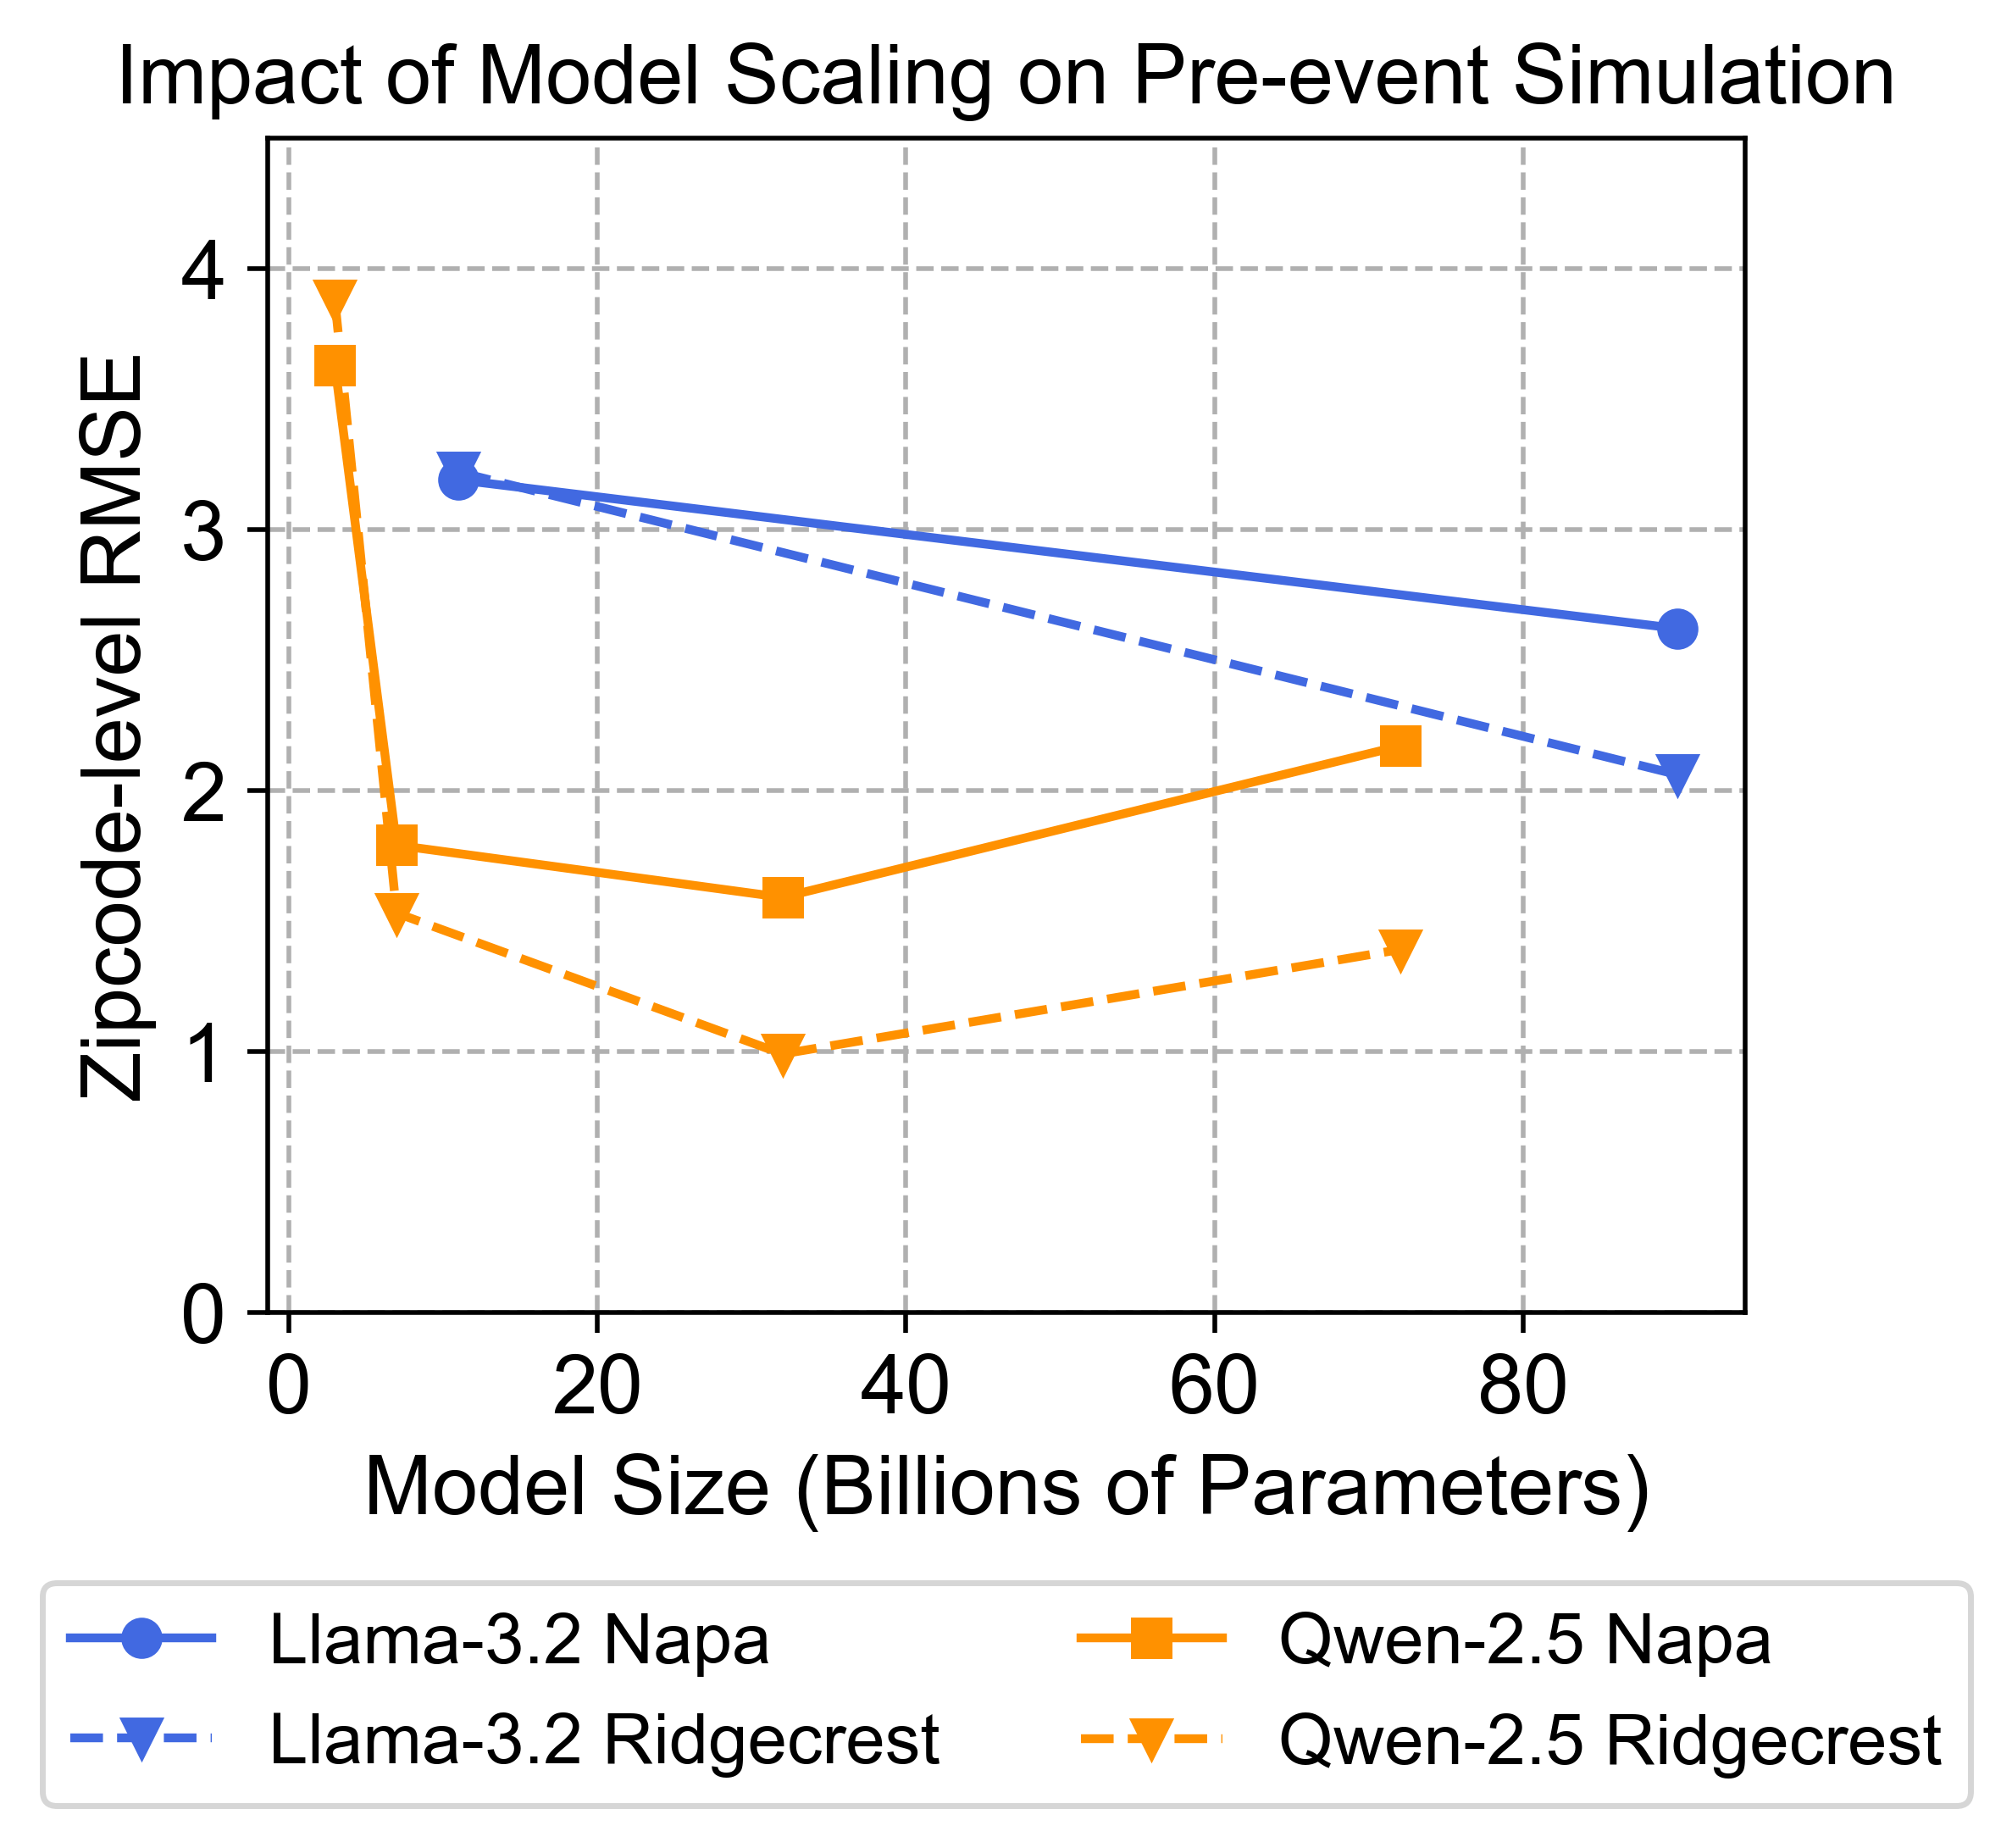

In [5]:
# Data extracted from the provided table
model_sizes_llama = [11, 90]  # in billions
zipcode_llama_napa = [3.19, 2.62]
zipcode_llama_ridgecrest = [3.22, 2.06]

model_sizes_qwen = [3, 7, 32, 72]  # in billions
zipcode_qwen_napa = [3.63, 1.79, 1.59, 2.17]
zipcode_qwen_ridgecrest = [3.88, 1.53, 0.99, 1.39]

# Plotting the scaling law
plt.figure(figsize=(4.5, 3.6))

# Llama-3.2
plt.plot(model_sizes_llama, zipcode_llama_napa, marker='o', linestyle='-', label='Llama-3.2 Napa', color="royalblue")
plt.plot(model_sizes_llama, zipcode_llama_ridgecrest, marker='v', linestyle='--', label='Llama-3.2 Ridgecrest' , color="royalblue",)

# Qwen-2.5
plt.plot(model_sizes_qwen, zipcode_qwen_napa, marker='s', linestyle='-', label='Qwen-2.5 Napa', color="#FF9100")
plt.plot(model_sizes_qwen, zipcode_qwen_ridgecrest, marker='v', linestyle='--', label='Qwen-2.5 Ridgecrest', color="#FF9100")

# Labels and title
plt.xlabel('Model Size (Billions of Parameters)')
plt.ylabel('Zipcode-level RMSE')
plt.title('Impact of Model Scaling on Pre-event Simulation')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=True, fontsize=12)

plt.xticks()
plt.yticks()    
plt.ylim(0, 4.5)
plt.grid(True, linestyle='--')

plt.savefig("scaling.pdf", format='pdf', bbox_inches='tight')
# plt.show()


In [ ]:
import numpy as np

# Data: full model scores
full_scores = {
    "Claude": {"Napa": 2.11, "Ridgcrest": 1.35},
    "Qwen": {"Napa": 1.78, "Ridgcrest": 1.53}
}

# Data: ablated model scores
ablations = {
    "Claude": {
        "w/o Geospatial": {"Napa": 2.06, "Ridgcrest": 1.28},
        "w/o Building": {"Napa": 1.90, "Ridgcrest": 1.03},
        "w/o Community": {"Napa": 1.86, "Ridgcrest": 0.82},
        "w/o Visual": {"Napa": 2.20, "Ridgcrest": 1.55}
    },
    "Qwen": {
        "w/o Geospatial": {"Napa": 1.12, "Ridgcrest": 0.69},
        "w/o Building": {"Napa": 1.21, "Ridgcrest": 0.85},
        "w/o Community": {"Napa": 0.79, "Ridgcrest": 0.69},
        "w/o Visual": {"Napa": 2.37, "Ridgcrest": 1.99}
    }
}

info_types = ["w/o Geospatial", "w/o Building", "w/o Community", "w/o Visual"]
scenarios = ["Napa", "Ridgcrest"]

x = np.arange(len(info_types))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for i, scenario in enumerate(scenarios):
    ax = axes[i]
    drop_claude = [full_scores["Claude"][scenario] - ablations["Claude"][info][scenario] for info in info_types]
    drop_qwen = [full_scores["Qwen"][scenario] - ablations["Qwen"][info][scenario] for info in info_types]

    ax.bar(x - width/2, drop_claude, width, label='Claude-3.5', color="royalblue")
    ax.bar(x + width/2, drop_qwen, width, label='Qwen-2.5-7B', color="#FF9100")

    ax.set_title("Effect of Each Information Type in "+scenario)
    ax.set_xticks(x)
    ax.set_xticklabels([info.capitalize() for info in info_types])
    ax.set_ylabel('Changes in Zip Code-level RMSE')
    ax.legend(fontsize=14, loc="lower left")
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
# plt.show()
plt.savefig("information.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [ ]:
# Data
full_scores = {
    "Claude": {"Napa": 2.11, "Ridgcrest": 1.35},
    "Qwen": {"Napa": 1.78, "Ridgcrest": 1.53}
}

ablations = {
    "Claude": {
        "w/o Geospatial": {"Napa": 2.06, "Ridgcrest": 1.28},
        "w/o Building": {"Napa": 1.90, "Ridgcrest": 1.03},
        "w/o Socioeconomic": {"Napa": 1.86, "Ridgcrest": 0.82},
        "w/o Streetview": {"Napa": 2.20, "Ridgcrest": 1.55}
    },
    "Qwen": {
        "w/o Geospatial": {"Napa": 1.12, "Ridgcrest": 0.69},
        "w/o Building": {"Napa": 1.21, "Ridgcrest": 0.85},
        "w/o Socioeconomic": {"Napa": 0.79, "Ridgcrest": 0.69},
        "w/o Streetview": {"Napa": 2.37, "Ridgcrest": 1.99}
    }
}

info_types = ["w/o Streetview", "w/o Socioeconomic", "w/o Building", "w/o Geospatial"]
scenarios = ["Napa", "Ridgcrest"]

# Bar positions
x = np.arange(len(info_types))
height = 0.2

fig, ax = plt.subplots(figsize=(5.5, 5))

# Data preparation
drop_claude_napa = [full_scores["Claude"]["Napa"] - ablations["Claude"][info]["Napa"] for info in info_types]
drop_claude_ridgcrest = [full_scores["Claude"]["Ridgcrest"] - ablations["Claude"][info]["Ridgcrest"] for info in info_types]
drop_qwen_napa = [full_scores["Qwen"]["Napa"] - ablations["Qwen"][info]["Napa"] for info in info_types]
drop_qwen_ridgcrest = [full_scores["Qwen"]["Ridgcrest"] - ablations["Qwen"][info]["Ridgcrest"] for info in info_types]

# Plot bars
ax.barh(x - 1.5*height, drop_claude_napa, height, label='Claude-3.5 Napa', color="royalblue")
ax.barh(x - 0.5*height, drop_claude_ridgcrest, height, label='Claude-3.5 Ridgcrest', color="lightblue")
ax.barh(x + 0.5*height, drop_qwen_napa, height, label='Qwen-2.5-7B Napa', color="#FF9100")
ax.barh(x + 1.5*height, drop_qwen_ridgcrest, height, label='Qwen-2.5-7B Ridgcrest', color="navajowhite")

# Set labels and titles
ax.set_yticks(x)
ax.set_yticklabels([info.capitalize() for info in info_types])
ax.set_xlabel('Drop in Zip Code-level RMSE')
ax.set_title('Combined Effect of Each Information Type')
ax.legend(loc='upper center', bbox_to_anchor=(0.4, -0.2), ncol=2, frameon=True, fontsize=13)


ax.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig("information.pdf", format='pdf', bbox_inches='tight')
plt.show()

NameError: name 'np' is not defined